In [61]:
import numpy as np
import pandas as pd

def generate_atm_veri_kumesi(
    n_satir=240000,
    random_state=42,
    baslangic="2024-01-01 00:00:00",
    bitis="2024-12-31 23:59:59"
):
    rng = np.random.default_rng(random_state)

    musteri_sayisi = 1500
    atm_sayisi = 80

    lokasyonlar = [
        "Istanbul_Kadikoy","Istanbul_Besiktas","Istanbul_Umraniye",
        "Ankara_Cankaya","Ankara_Keçiören",
        "Izmir_Karsiyaka","Bursa_Nilufer","Antalya_Muratpasa"
    ]

    atm_idler = np.arange(1, atm_sayisi + 1)
    atm_lokasyonlari = rng.choice(lokasyonlar, size=atm_sayisi, replace=True)
    atm_tablo = pd.DataFrame({"atm_id": atm_idler, "atm_konumu": atm_lokasyonlari})

    baslangic_zaman = pd.Timestamp(baslangic)
    bitis_zaman = pd.Timestamp(bitis)
    toplam_saniye = int((bitis_zaman - baslangic_zaman).total_seconds())

    rastgele_saniyeler = rng.integers(0, toplam_saniye + 1, size=n_satir)
    zaman_damgalari = baslangic_zaman + pd.to_timedelta(rastgele_saniyeler, unit="s")

    musteri_idler = rng.integers(1, musteri_sayisi + 1, size=n_satir)
    secilen_atm_idler = rng.choice(atm_idler, size=n_satir, replace=True)

    ham_tutarlar = rng.lognormal(mean=5.3, sigma=0.6, size=n_satir)
    tutarlar = np.clip(ham_tutarlar, 50, 5000).round(2)

    hatali_deneme_sayisi = np.clip(rng.poisson(lam=0.3, size=n_satir), 0, 6)

    islem_sureleri = np.clip(rng.normal(loc=35, scale=8, size=n_satir), 5, 150).round(1)

    durumlar = np.where(rng.random(n_satir) < 0.9, "success", "failed")

    df = pd.DataFrame({
        "islem_id": np.arange(1, n_satir + 1),
        "zaman_damgasi": zaman_damgalari,
        "musteri_id": musteri_idler,
        "atm_id": secilen_atm_idler,
        "tutar": tutarlar,
        "hatali_deneme_sayisi": hatali_deneme_sayisi,
        "islem_suresi_sn": islem_sureleri,
        "durum": durumlar
    })

    df = df.merge(atm_tablo, on="atm_id", how="left")

    df["saat"] = df["zaman_damgasi"].dt.hour
    df["haftanin_gunu"] = df["zaman_damgasi"].dt.dayofweek

    def saat_araligi_olustur(saat):
        if 0 <= saat < 6:
            return "night"
        elif 6 <= saat < 18:
            return "working_hours"
        else:
            return "evening"
    df["saat_araligi"] = df["saat"].apply(saat_araligi_olustur)

    df["anomali_mi"] = (rng.random(n_satir) < 0.05).astype(int)

    gece_maske = (df["anomali_mi"] == 1) & (df["saat_araligi"] == "night")
    df.loc[gece_maske, "tutar"] = np.clip(
        rng.normal(loc=3000, scale=500, size=gece_maske.sum()), 500, 5000
    ).round(2)

    cok_hata_maske = (df["anomali_mi"] == 1) & (rng.random(n_satir) < 0.4)
    df.loc[cok_hata_maske, "hatali_deneme_sayisi"] = rng.integers(3, 7, size=cok_hata_maske.sum())
    df.loc[cok_hata_maske, "durum"] = "failed"

    tuhaf_sure_maske = (df["anomali_mi"] == 1) & (rng.random(n_satir) < 0.4)
    tuhaf_sureler = rng.choice([rng.uniform(3, 8), rng.uniform(90, 150)], size=tuhaf_sure_maske.sum())
    df.loc[tuhaf_sure_maske, "islem_suresi_sn"] = np.clip(tuhaf_sureler, 3, 150).round(1)

    df = df.sort_values(["musteri_id", "zaman_damgasi"]).reset_index(drop=True)
    df["onceki_isleme_uzaklik_km"] = rng.exponential(scale=2, size=n_satir)

    uzak_maske = (df["anomali_mi"] == 1) & (rng.random(n_satir) < 0.3)
    df.loc[uzak_maske, "onceki_isleme_uzaklik_km"] = rng.uniform(300, 2000, size=uzak_maske.sum())
    df["onceki_isleme_uzaklik_km"] = df["onceki_isleme_uzaklik_km"].round(2)

    df = df.sort_values("zaman_damgasi").reset_index(drop=True)
    return df

# ✅ 1 yıllık veriyi üret ve kaydet
veri = generate_atm_veri_kumesi(n_satir=240000, random_state=42)
veri.to_csv("atm_islemleri_tr_1yil.csv", index=False)

print("Kaydedildi:", len(veri))
print("Tarih aralığı:", veri["zaman_damgasi"].min(), "→", veri["zaman_damgasi"].max())


Kaydedildi: 240000
Tarih aralığı: 2024-01-01 00:00:27 → 2024-12-31 23:56:41


In [62]:
import pandas as pd

veri = pd.read_csv("atm_islemleri_tr_1yil.csv")
veri["zaman_damgasi"] = pd.to_datetime(veri["zaman_damgasi"], errors="coerce")

num_cols = [
    "islem_id","musteri_id","atm_id","tutar",
    "hatali_deneme_sayisi","islem_suresi_sn",
    "onceki_isleme_uzaklik_km","saat","haftanin_gunu","anomali_mi"
]
for c in num_cols:
    if c in veri.columns:
        veri[c] = pd.to_numeric(veri[c], errors="coerce")

veri["tutar"] = veri["tutar"].clip(lower=0)
veri = veri.dropna(subset=["zaman_damgasi", "tutar"]).reset_index(drop=True)

print("Toplam satır:", len(veri))
print("Tarih aralığı:", veri["zaman_damgasi"].min(), "→", veri["zaman_damgasi"].max())
display(veri.head())


Toplam satır: 240000
Tarih aralığı: 2024-01-01 00:00:27 → 2024-12-31 23:56:41


,islem_id,zaman_damgasi,musteri_id,atm_id,tutar,hatali_deneme_sayisi,islem_suresi_sn,durum,atm_konumu,saat,haftanin_gunu,saat_araligi,anomali_mi,onceki_isleme_uzaklik_km
0,4963,2024-01-01 00:00:27,264,78,92.81,0,46.1,success,Istanbul_Besiktas,0,0,night,0,0.55
1,225813,2024-01-01 00:01:01,1196,40,400.26,0,48.6,success,Izmir_Karsiyaka,0,0,night,0,0.04
2,49346,2024-01-01 00:01:35,94,4,236.35,0,39.6,success,Ankara_Cankaya,0,0,night,0,3.98
3,20195,2024-01-01 00:06:56,1424,22,110.19,0,31.1,success,Istanbul_Umraniye,0,0,night,0,1.09
4,124537,2024-01-01 00:07:00,355,58,2929.15,0,3.0,success,Istanbul_Besiktas,0,0,night,1,0.17


In [63]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1) Veri setinin temel yapısı
print("Veri seti bilgisi (info):")
veri.info()

# 2) Satır / kolon ve tarih aralığı (1 yıl kanıtı)
print("\nBoyut (satır, sütun):", veri.shape)
print("Tarih aralığı:", veri["zaman_damgasi"].min(), "→", veri["zaman_damgasi"].max())

# 3) Eksik değer kontrolü
print("\nEksik değer sayıları:")
print(veri.isna().sum().sort_values(ascending=False).head(15))

# 4) Sayısal özet (describe)
print("\nSayısal değişkenler için özet istatistikler (describe):")
display(veri.describe().T)

# 5) Kategorik özet (durum, atm_konumu, saat_araligi varsa)
cat_cols = [c for c in ["durum", "atm_konumu", "saat_araligi"] if c in veri.columns]
for c in cat_cols:
    print(f"\n'{c}' dağılımı:")
    display(veri[c].value_counts(normalize=True).mul(100).round(2).rename("yüzde").to_frame())

# 6) Anomali oranı (hocaya net)
if "anomali_mi" in veri.columns:
    oran = veri["anomali_mi"].mean() * 100
    print(f"\nAnomali oranı: %{oran:.2f} (1=anomali)")
    print("Anomali sayısı:", int(veri["anomali_mi"].sum()))


Veri seti bilgisi (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   islem_id                  240000 non-null  int64         
 1   zaman_damgasi             240000 non-null  datetime64[ns]
 2   musteri_id                240000 non-null  int64         
 3   atm_id                    240000 non-null  int64         
 4   tutar                     240000 non-null  float64       
 5   hatali_deneme_sayisi      240000 non-null  int64         
 6   islem_suresi_sn           240000 non-null  float64       
 7   durum                     240000 non-null  object        
 8   atm_konumu                240000 non-null  object        
 9   saat                      240000 non-null  int64         
 10  haftanin_gunu             240000 non-null  int64         
 11  saat_araligi              240000 non-nu

,count,mean,min,25%,50%,75%,max,std
islem_id,240000.0,120000.5,1.0,60000.75,120000.5,180000.25,240000.0,69282.17664
zaman_damgasi,240000,2024-07-02 03:06:20.657241344,2024-01-01 00:00:27,2024-04-01 17:46:56.750000128,2024-07-02 05:12:58.500000,2024-10-01 09:23:42.249999872,2024-12-31 23:56:41,NaN
musteri_id,240000.0,750.124329,1.0,373.0,751.0,1125.0,1500.0,433.253172
atm_id,240000.0,40.464108,1.0,20.0,40.0,60.0,80.0,23.076532
tutar,240000.0,274.260661,50.0,134.37,201.85,305.64,4727.84,350.249796
hatali_deneme_sayisi,240000.0,0.386021,0.0,0.0,0.0,1.0,6.0,0.81813
islem_suresi_sn,240000.0,35.468042,3.0,29.5,35.0,40.5,109.8,11.301923
saat,240000.0,11.487071,0.0,5.0,11.0,17.0,23.0,6.92294
haftanin_gunu,240000.0,2.9906,0.0,1.0,3.0,5.0,6.0,2.002516
anomali_mi,240000.0,0.049625,0.0,0.0,0.0,0.0,1.0,0.217169



'durum' dağılımı:


,yüzde
durum,
success,88.19
failed,11.81



'atm_konumu' dağılımı:


,yüzde
atm_konumu,
Ankara_Cankaya,16.31
Izmir_Karsiyaka,16.19
Bursa_Nilufer,16.13
Istanbul_Besiktas,12.61
Antalya_Muratpasa,10.11
Istanbul_Umraniye,10.00
Istanbul_Kadikoy,9.94
Ankara_Keçiören,8.71



'saat_araligi' dağılımı:


,yüzde
saat_araligi,
working_hours,50.02
night,25.06
evening,24.92



Anomali oranı: %4.96 (1=anomali)
Anomali sayısı: 11910


In [64]:
# Orijinal veriyi bozmamak için eksik değer işlemlerini kopya üzerinde çalışıyoruz
veri_eksik = veri.copy()

rng = np.random.default_rng(42)
n = len(veri_eksik)

# %1 eksik tutar
eksik_indeks_tutar = rng.choice(n, size=int(n * 0.01), replace=False)
veri_eksik.loc[eksik_indeks_tutar, "tutar"] = np.nan

# %0.5 eksik işlem süresi
eksik_indeks_sure = rng.choice(n, size=int(n * 0.005), replace=False)
veri_eksik.loc[eksik_indeks_sure, "islem_suresi_sn"] = np.nan

# %0.5 eksik ATM konumu (kolon varsa)
if "atm_konumu" in veri_eksik.columns:
    eksik_indeks_konum = rng.choice(n, size=int(n * 0.005), replace=False)
    veri_eksik.loc[eksik_indeks_konum, "atm_konumu"] = np.nan

print("Eksik değer sayıları (enjeksiyon sonrası):")
display(veri_eksik.isnull().sum())


Eksik değer sayıları (enjeksiyon sonrası):


islem_id                       0
zaman_damgasi                  0
musteri_id                     0
atm_id                         0
tutar                       2400
hatali_deneme_sayisi           0
islem_suresi_sn             1200
durum                          0
atm_konumu                  1200
saat                           0
haftanin_gunu                  0
saat_araligi                   0
anomali_mi                     0
onceki_isleme_uzaklik_km       0
dtype: int64

In [65]:
print("Eksik değer sayıları (doldurmadan önce):")
display(veri_eksik.isnull().sum())

# Sayısal değişkenleri medyan ile dolduralım (outlier'a daha dayanıklı)
sayisal_sutunlar = ["tutar", "islem_suresi_sn"]

for sutun in sayisal_sutunlar:
    if sutun in veri_eksik.columns:
        medyan_deger = veri_eksik[sutun].median()
        veri_eksik[sutun] = veri_eksik[sutun].fillna(medyan_deger)
        print(f"'{sutun}' sütunundaki eksikler medyan ({medyan_deger}) ile dolduruldu.")

# Kategorik sütun: atm_konumu -> en sık görülen değer (mod)
if "atm_konumu" in veri_eksik.columns:
    mod_konum = veri_eksik["atm_konumu"].mode(dropna=True)[0]
    veri_eksik["atm_konumu"] = veri_eksik["atm_konumu"].fillna(mod_konum)
    print(f"'atm_konumu' sütunundaki eksikler mod ({mod_konum}) ile dolduruldu.")

print("\nEksik değer sayıları (doldurduktan sonra):")
display(veri_eksik.isnull().sum())


Eksik değer sayıları (doldurmadan önce):


islem_id                       0
zaman_damgasi                  0
musteri_id                     0
atm_id                         0
tutar                       2400
hatali_deneme_sayisi           0
islem_suresi_sn             1200
durum                          0
atm_konumu                  1200
saat                           0
haftanin_gunu                  0
saat_araligi                   0
anomali_mi                     0
onceki_isleme_uzaklik_km       0
dtype: int64

'tutar' sütunundaki eksikler medyan (201.85500000000002) ile dolduruldu.
'islem_suresi_sn' sütunundaki eksikler medyan (35.0) ile dolduruldu.
'atm_konumu' sütunundaki eksikler mod (Ankara_Cankaya) ile dolduruldu.

Eksik değer sayıları (doldurduktan sonra):


islem_id                    0
zaman_damgasi               0
musteri_id                  0
atm_id                      0
tutar                       0
hatali_deneme_sayisi        0
islem_suresi_sn             0
durum                       0
atm_konumu                  0
saat                        0
haftanin_gunu               0
saat_araligi                0
anomali_mi                  0
onceki_isleme_uzaklik_km    0
dtype: int64

In [66]:
# =========================
# AYKIRI DEĞER ANALİZİ VE TEMİZLİĞİ (Adım Adım Gösterim)
# =========================

# Veri setini tanımla (Karışıklık olmasın)
veri = veri_eksik.copy()

print("### ADIM 1: İstatistiksel Sınırların Hesaplanması (IQR) ###")

# 1. Çeyrekler ve IQR Hesaplama
Q1 = veri["tutar"].quantile(0.25)
Q3 = veri["tutar"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (Alt Çeyrek - %25): {Q1:.2f}")
print(f"Q3 (Üst Çeyrek - %75): {Q3:.2f}")
print(f"IQR Değeri (Q3 - Q1): {IQR:.2f}")

# 2. Sınırları Hesaplama
alt_sinir_hesaplanan = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"\n### ADIM 2: Sınır Kontrolü ve Düzeltme ###")
print(f"Matematiksel Alt Sınır: {alt_sinir_hesaplanan:.2f}")
print(f"Matematiksel Üst Sınır: {ust_sinir:.2f}")

# 3. Domain Bilgisi ile Müdahale (Senin dediğin Negatiflik Durumu)
# ATM'den negatif para çekilemeyeceği için alt sınırı 0'a sabitliyoruz.
if alt_sinir_hesaplanan < 0:
    print("-> UYARI: Alt sınır negatif çıktı. Bankacılık mantığı gereği 0'a eşitlendi.")
    alt_sinir = 0
else:
    alt_sinir = alt_sinir_hesaplanan

print(f"KULLANILAN FİNAL ALT SINIR: {alt_sinir}")
print(f"KULLANILAN FİNAL ÜST SINIR: {ust_sinir:.2f}")

# 4. Aykırı Değerleri Yakalama (Maskeleme)
# Alt sınırdan küçük VEYA üst sınırdan büyük olanlar aykırıdır.
aykiri_maske = (veri["tutar"] < alt_sinir) | (veri["tutar"] > ust_sinir)
aykiri_sayisi = aykiri_maske.sum()
toplam_veri = len(veri)

print(f"\n### ADIM 3: Tespit Sonuçları ###")
print(f"Toplam Veri Sayısı: {toplam_veri}")
print(f"Tespit Edilen Aykırı Değer Sayısı: {aykiri_sayisi}")
print(f"Aykırı Değer Oranı: %{100 * aykiri_sayisi / toplam_veri:.2f}")

print("\n### ADIM 4: Aykırı Değerlerden Örnekler (Kanıt) ###")
# Aykırı olan satırları gösteriyoruz
try:
    # Sadece ilgili sütunları seçip gösterelim
    ornekler = veri.loc[aykiri_maske, ["tutar", "islem_suresi_sn", "hatali_deneme_sayisi", "anomali_mi"]].head()
    display(ornekler)
except:
    print(veri.loc[aykiri_maske, ["tutar", "anomali_mi"]].head())

# 5. Temizlenmiş Veriyi Oluşturma
veri_temiz = veri[~aykiri_maske]
print(f"\n-> Temizlenmiş Veri Seti Boyutu: {len(veri_temiz)}")
print("İşlem Başarıyla Tamamlandı. ✅")

### ADIM 1: İstatistiksel Sınırların Hesaplanması (IQR) ###
Q1 (Alt Çeyrek - %25): 135.04
Q3 (Üst Çeyrek - %75): 304.26
IQR Değeri (Q3 - Q1): 169.22

### ADIM 2: Sınır Kontrolü ve Düzeltme ###
Matematiksel Alt Sınır: -118.79
Matematiksel Üst Sınır: 558.09
-> UYARI: Alt sınır negatif çıktı. Bankacılık mantığı gereği 0'a eşitlendi.
KULLANILAN FİNAL ALT SINIR: 0
KULLANILAN FİNAL ÜST SINIR: 558.09

### ADIM 3: Tespit Sonuçları ###
Toplam Veri Sayısı: 240000
Tespit Edilen Aykırı Değer Sayısı: 13239
Aykırı Değer Oranı: %5.52

### ADIM 4: Aykırı Değerlerden Örnekler (Kanıt) ###


,tutar,islem_suresi_sn,hatali_deneme_sayisi,anomali_mi
4,2929.15,3.0,0,1
13,2561.14,42.7,6,1
21,707.21,52.0,0,0
26,591.03,42.9,0,0
49,712.75,30.8,0,0



-> Temizlenmiş Veri Seti Boyutu: 226761
İşlem Başarıyla Tamamlandı. ✅


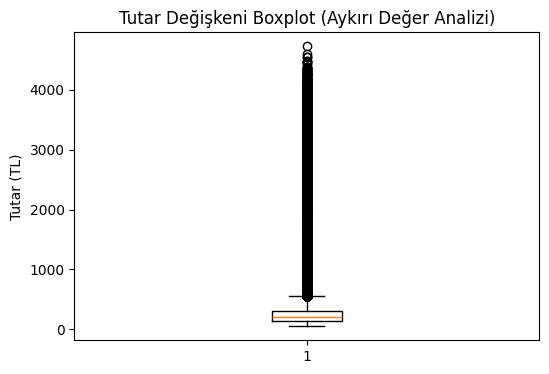

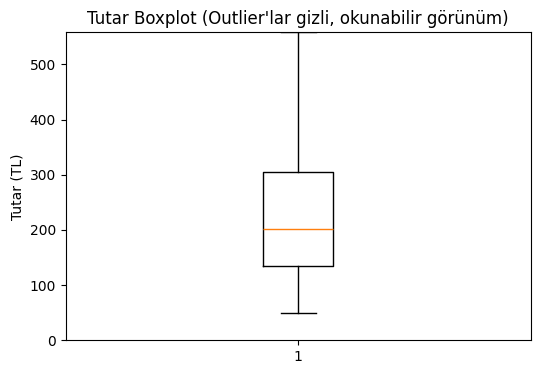

Zoom üst sınır (Q3 + 1.5*IQR): 558.09


In [67]:
import matplotlib.pyplot as plt

# 1) Normal boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(veri_eksik["tutar"], vert=True)
plt.title("Tutar Değişkeni Boxplot (Aykırı Değer Analizi)")
plt.ylabel("Tutar (TL)")
plt.show()

# 2) Zoomlu boxplot (okunabilirlik için üst sınırda kesiyoruz)
Q1 = veri_eksik["tutar"].quantile(0.25)
Q3 = veri_eksik["tutar"].quantile(0.75)
IQR = Q3 - Q1
ust_sinir = Q3 + 1.5 * IQR

plt.figure(figsize=(6, 4))
plt.boxplot(veri_eksik["tutar"], vert=True, showfliers=False)  # outlier noktalarını gizle
plt.title("Tutar Boxplot (Outlier'lar gizli, okunabilir görünüm)")
plt.ylabel("Tutar (TL)")
plt.ylim(0, ust_sinir)  # ✅ zoom
plt.show()

print("Zoom üst sınır (Q3 + 1.5*IQR):", round(ust_sinir, 2))


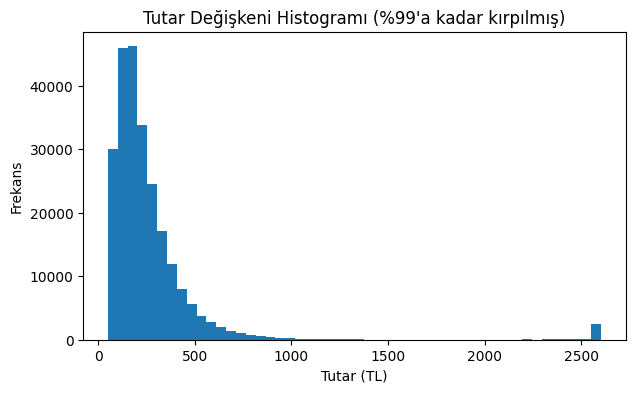

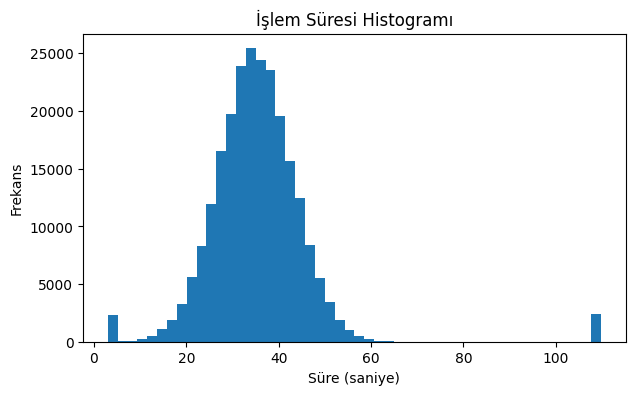

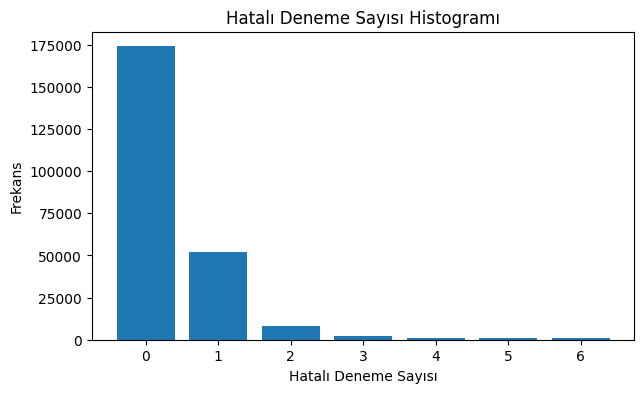

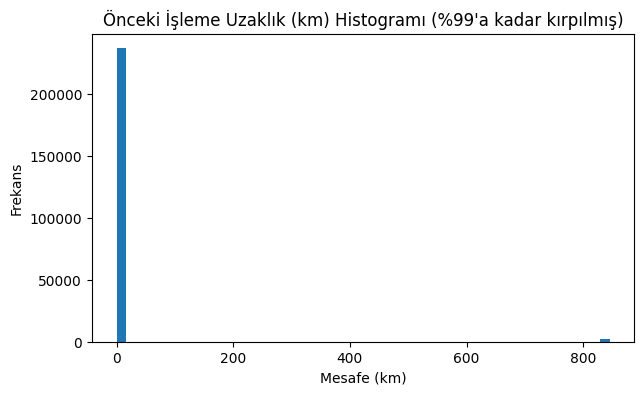

In [68]:
import matplotlib.pyplot as plt

# 1) Tutar dağılımı (outlier etkisini azaltmak için %99'a kadar kırp)
tutar_kirp = veri_eksik["tutar"].dropna().clip(upper=veri_eksik["tutar"].quantile(0.99))

plt.figure(figsize=(7, 4))
plt.hist(tutar_kirp, bins=50)
plt.title("Tutar Değişkeni Histogramı (%99'a kadar kırpılmış)")
plt.xlabel("Tutar (TL)")
plt.ylabel("Frekans")
plt.show()

# 2) İşlem süresi dağılımı
sure = veri_eksik["islem_suresi_sn"].dropna()

plt.figure(figsize=(7, 4))
plt.hist(sure, bins=50)
plt.title("İşlem Süresi Histogramı")
plt.xlabel("Süre (saniye)")
plt.ylabel("Frekans")
plt.show()

# 3) Hatalı deneme sayısı (tam sayılar olduğu için bins'i düzgün verelim)
hata = veri_eksik["hatali_deneme_sayisi"].dropna()
max_hata = int(hata.max())

plt.figure(figsize=(7, 4))
plt.hist(hata, bins=range(0, max_hata + 2), align="left", rwidth=0.8)
plt.title("Hatalı Deneme Sayısı Histogramı")
plt.xlabel("Hatalı Deneme Sayısı")
plt.ylabel("Frekans")
plt.xticks(range(0, max_hata + 1))
plt.show()

# 4) Önceki işleme uzaklık (km) (outlier etkisini azaltmak için %99'a kadar kırp)
mesafe_kirp = veri_eksik["onceki_isleme_uzaklik_km"].dropna().clip(
    upper=veri_eksik["onceki_isleme_uzaklik_km"].quantile(0.99)
)

plt.figure(figsize=(7, 4))
plt.hist(mesafe_kirp, bins=50)
plt.title("Önceki İşleme Uzaklık (km) Histogramı (%99'a kadar kırpılmış)")
plt.xlabel("Mesafe (km)")
plt.ylabel("Frekans")
plt.show()


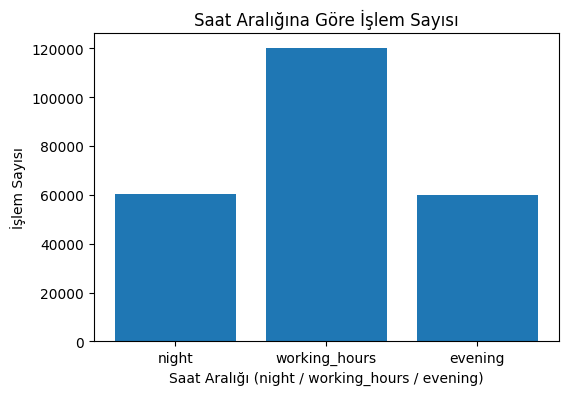

Saat aralığı dağılımı (adet):
saat_araligi
night             60144
working_hours    120043
evening           59813
Name: count, dtype: int64

Saat aralığı dağılımı (%):
saat_araligi
night            25.06
working_hours    50.02
evening          24.92
Name: count, dtype: float64


In [69]:
import matplotlib.pyplot as plt

if "saat_araligi" not in veri_eksik.columns:
    # Eğer yoksa saatten türet
    def saat_araligi_olustur(saat):
        if 0 <= saat < 6:
            return "night"
        elif 6 <= saat < 18:
            return "working_hours"
        else:
            return "evening"
    veri_eksik["saat_araligi"] = veri_eksik["saat"].apply(saat_araligi_olustur)

# Sıralamayı sabitle
sirali_kategoriler = ["night", "working_hours", "evening"]
saat_sayim = veri_eksik["saat_araligi"].value_counts().reindex(sirali_kategoriler).fillna(0).astype(int)

plt.figure(figsize=(6, 4))
plt.bar(saat_sayim.index, saat_sayim.values)
plt.title("Saat Aralığına Göre İşlem Sayısı")
plt.xlabel("Saat Aralığı (night / working_hours / evening)")
plt.ylabel("İşlem Sayısı")
plt.show()

print("Saat aralığı dağılımı (adet):")
print(saat_sayim)

print("\nSaat aralığı dağılımı (%):")
print((saat_sayim / saat_sayim.sum() * 100).round(2))


In [70]:
import pandas as pd

sayisal_deg = [
    "tutar",
    "islem_suresi_sn",
    "hatali_deneme_sayisi",
    "onceki_isleme_uzaklik_km"
]

istatistik_listesi = []

for sutun in sayisal_deg:
    if sutun not in veri_eksik.columns:
        continue

    seri = veri_eksik[sutun].dropna()

    istatistik_listesi.append({
        "degisken": sutun,
        "ortalama": round(seri.mean(), 3),
        "medyan": round(seri.median(), 3),
        "varyans": round(seri.var(), 3),
        "carpiklik (skewness)": round(seri.skew(), 3),
        "basiklik (kurtosis)": round(seri.kurt(), 3)
    })

istatistik_df = pd.DataFrame(istatistik_listesi)
display(istatistik_df)


,degisken,ortalama,medyan,varyans,carpiklik (skewness),basiklik (kurtosis)
0,tutar,273.617,201.855,121623.707,6.748,54.163
1,islem_suresi_sn,35.463,35.000,126.898,2.540,17.068
2,hatali_deneme_sayisi,0.386,0.000,0.669,3.535,16.778
3,onceki_isleme_uzaklik_km,18.838,1.420,22506.653,9.775,100.107


In [71]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Ölçeklenecek sayısal kolonlar
olcek_cols = ["tutar", "islem_suresi_sn", "hatali_deneme_sayisi", "onceki_isleme_uzaklik_km"]
olcek_cols = [c for c in olcek_cols if c in veri_eksik.columns]

# NaN kalmışsa ölçekleme öncesi dolduralım (en güvenlisi: medyan)
X = veri_eksik[olcek_cols].copy()
X = X.fillna(X.median(numeric_only=True))

# 1) Min-Max (0-1)
minmax_olcekleyici = MinMaxScaler()
X_minmax = minmax_olcekleyici.fit_transform(X)
X_minmax = pd.DataFrame(X_minmax, columns=[f"{c}_minmax" for c in olcek_cols], index=veri_eksik.index)

# 2) Z-Score (StandardScaler)
zskor_olcekleyici = StandardScaler()
X_zskor = zskor_olcekleyici.fit_transform(X)
X_zskor = pd.DataFrame(X_zskor, columns=[f"{c}_zskor" for c in olcek_cols], index=veri_eksik.index)

# 3) RobustScaler (aykırı değerlere dayanıklı)
robust_olcekleyici = RobustScaler()
X_robust = robust_olcekleyici.fit_transform(X)
X_robust = pd.DataFrame(X_robust, columns=[f"{c}_robust" for c in olcek_cols], index=veri_eksik.index)

# Sonuçları veri_eksik'e ekle
veri_eksik = pd.concat([veri_eksik, X_minmax, X_zskor, X_robust], axis=1)

# Örnek çıktı (ilk 5 satır)
goster_cols = olcek_cols + [f"{c}_minmax" for c in olcek_cols] + [f"{c}_zskor" for c in olcek_cols] + [f"{c}_robust" for c in olcek_cols]
display(veri_eksik[goster_cols].head())


,tutar,islem_suresi_sn,hatali_deneme_sayisi,onceki_isleme_uzaklik_km,tutar_minmax,islem_suresi_sn_minmax,hatali_deneme_sayisi_minmax,onceki_isleme_uzaklik_km_minmax,tutar_zskor,islem_suresi_sn_zskor,hatali_deneme_sayisi_zskor,onceki_isleme_uzaklik_km_zskor,tutar_robust,islem_suresi_sn_robust,hatali_deneme_sayisi_robust,onceki_isleme_uzaklik_km_robust
0,92.81,35.0,0,0.55,0.009152,0.299625,0.0,0.000275,-0.518451,-0.041069,-0.471834,-0.121902,-0.644398,0.000000,0.0,-0.381579
1,400.26,48.6,0,0.04,0.074876,0.426966,0.0,0.000020,0.363138,1.166220,-0.471834,-0.125301,1.172468,1.247706,0.0,-0.605263
2,236.35,39.6,0,3.98,0.039837,0.342697,0.0,0.001990,-0.106861,0.367279,-0.471834,-0.099038,0.203847,0.422018,0.0,1.122807
3,110.19,31.1,0,1.09,0.012867,0.263109,0.0,0.000545,-0.468615,-0.387278,-0.471834,-0.118302,-0.541691,-0.357798,0.0,-0.144737
4,2929.15,3.0,0,0.17,0.615487,0.000000,0.0,0.000085,7.614536,-2.881752,-0.471834,-0.124435,16.116860,-2.935780,0.0,-0.548246


In [72]:
# =========================
# 3. REGRESYON ANALİZİ (İstatistiksel Detaylı - P-Value İçerir)
# =========================
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("\n### 3. REGRESYON ANALİZİ (Akademik Rapor) ###")

# Değişkenleri Belirle
X = veri[["islem_suresi_sn", "hatali_deneme_sayisi", "saat", "onceki_isleme_uzaklik_km"]]
y = veri["tutar"]

# 1. Veriyi Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalizasyon (Ölçekleme)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- KRİTİK ADIM: Statsmodels için Sabit (Intercept) Ekleme ---
# Sklearn bunu otomatik yapar ama Statsmodels'te elle eklemeliyiz.
X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols = sm.add_constant(X_test_scaled)

# 3. Modeli Kurma (OLS: Ordinary Least Squares)
model_ols = sm.OLS(y_train, X_train_ols).fit()

# 4. HOCANIN İSTEDİĞİ O MEŞHUR TABLO (Summary)
print(model_ols.summary())

# --- Yorumlama Kısmı (Otomatik) ---
print("\n--- P-Değeri Analizi (Hocanın Uyarısı) ---")
p_values = model_ols.pvalues
degisken_isimleri = ["Sabit (Bias)"] + list(X.columns)

for i, p_val in enumerate(p_values):
    degisken = degisken_isimleri[i]
    if p_val < 0.05:
        print(f"✅ {degisken}: P-value={p_val:.4f} (<0.05). İlişki ANLAMLI ve GÜVENİLİR.")
    else:
        print(f"❌ {degisken}: P-value={p_val:.4f} (>0.05). İlişki GÜVENİLİR DEĞİL (Şans eseri olabilir).")
       


### 3. REGRESYON ANALİZİ (Akademik Rapor) ###
                            OLS Regression Results                            
Dep. Variable:                  tutar   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     4333.
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        02:46:55   Log-Likelihood:            -1.3879e+06
No. Observations:              192000   AIC:                         2.776e+06
Df Residuals:                  191995   BIC:                         2.776e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

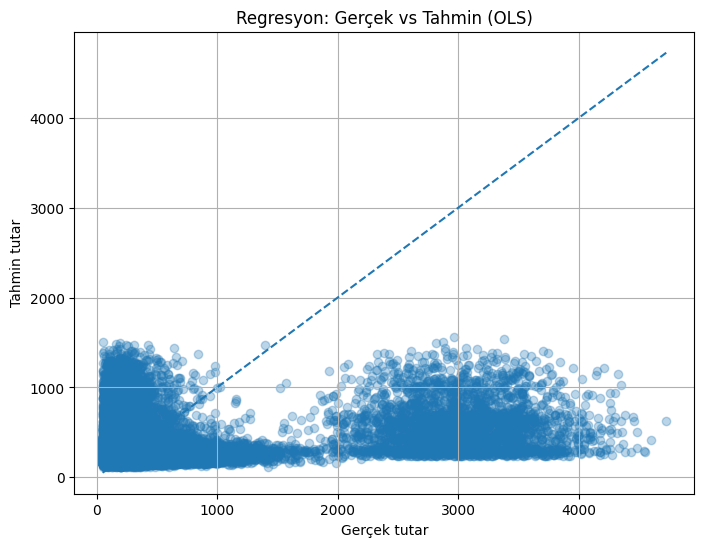

In [73]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# X ve y (regresyon için)
X_reg = veri_eksik[["islem_suresi_sn", "hatali_deneme_sayisi", "saat", "onceki_isleme_uzaklik_km"]]
y_reg = veri_eksik["tutar"]

# OLS model
X_ols = sm.add_constant(X_reg)
ols_model = sm.OLS(y_reg, X_ols).fit()

# Tahmin
y_pred = ols_model.predict(X_ols)

# Grafik
plt.figure(figsize=(8, 6))
plt.scatter(y_reg, y_pred, alpha=0.3)
mn = min(y_reg.min(), y_pred.min())
mx = max(y_reg.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Regresyon: Gerçek vs Tahmin (OLS)")
plt.xlabel("Gerçek tutar")
plt.ylabel("Tahmin tutar")
plt.grid(True)
plt.show()


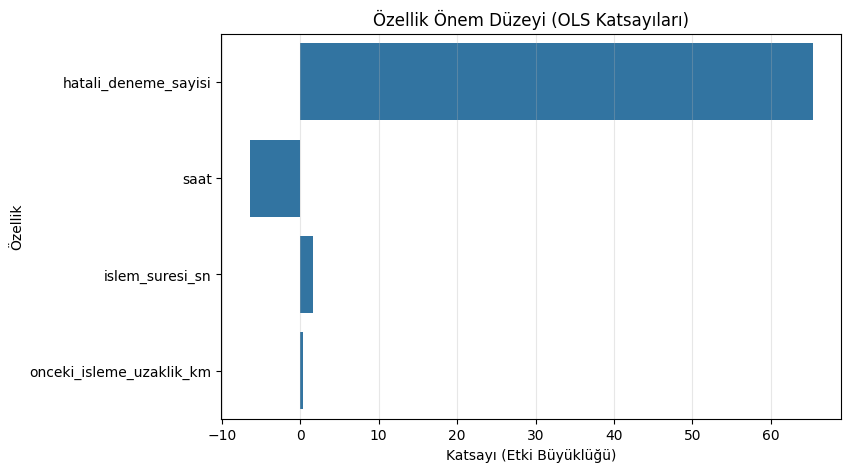

In [74]:
import seaborn as sns
import pandas as pd

# --- 4. ÖZELLİK ÖNEM DÜZEYİ (Katsayılar) ---

# OLS katsayıları (const'u atıyoruz)
katsayilar = pd.DataFrame({
    "Ozellik": X_reg.columns,
    "Etki_Katsayisi": ols_model.params[X_reg.columns].values  # const hariç sadece feature'lar
})

# Mutlak değere göre sırala (büyüklüğe göre)
katsayilar = katsayilar.sort_values(by="Etki_Katsayisi", key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=katsayilar, x="Etki_Katsayisi", y="Ozellik")
plt.title("Özellik Önem Düzeyi (OLS Katsayıları)")
plt.xlabel("Katsayı (Etki Büyüklüğü)")
plt.ylabel("Özellik")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


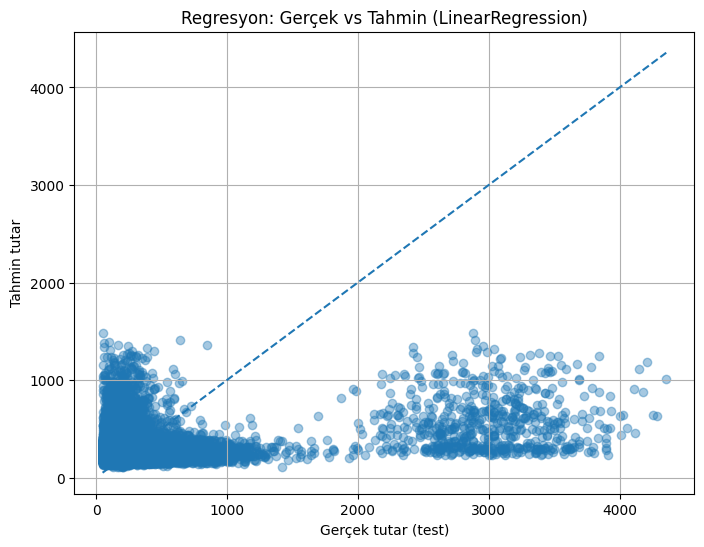

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_reg = veri_eksik[["islem_suresi_sn", "hatali_deneme_sayisi", "saat", "onceki_isleme_uzaklik_km"]]
y_reg = veri_eksik["tutar"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lin_model = LinearRegression()
lin_model.fit(X_train_s, y_train)
y_pred = lin_model.predict(X_test_s)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Regresyon: Gerçek vs Tahmin (LinearRegression)")
plt.xlabel("Gerçek tutar (test)")
plt.ylabel("Tahmin tutar")
plt.grid(True)
plt.show()



### 1. KORELASYON ANALİZİ (Spearman) ###


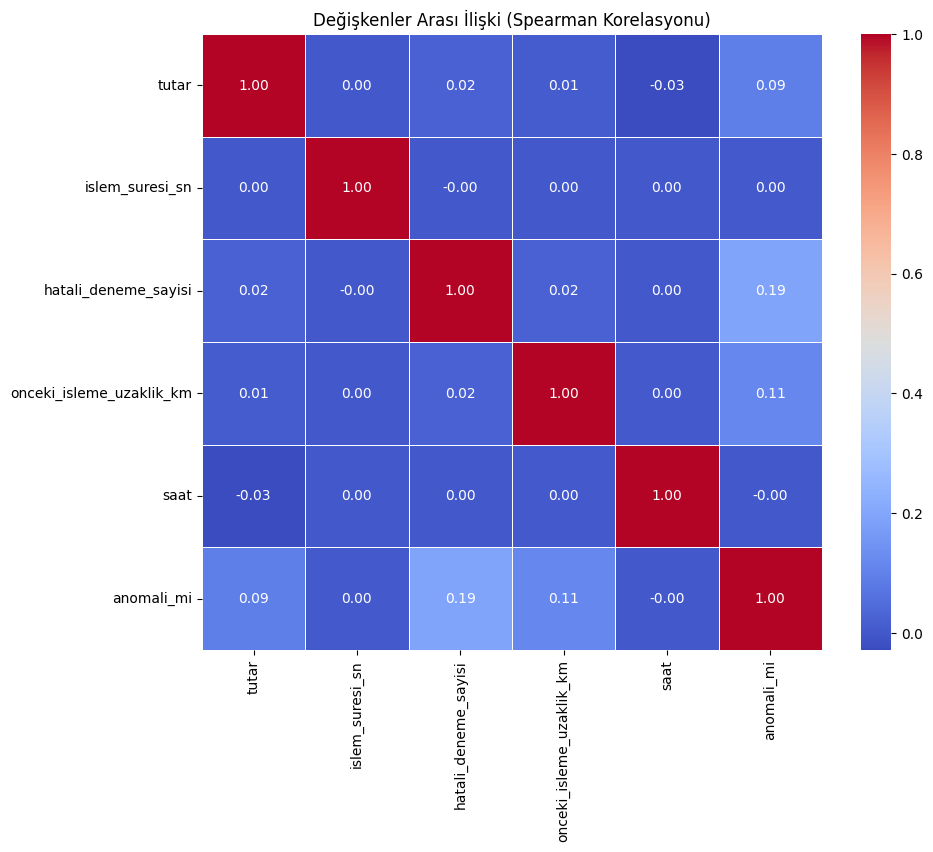

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


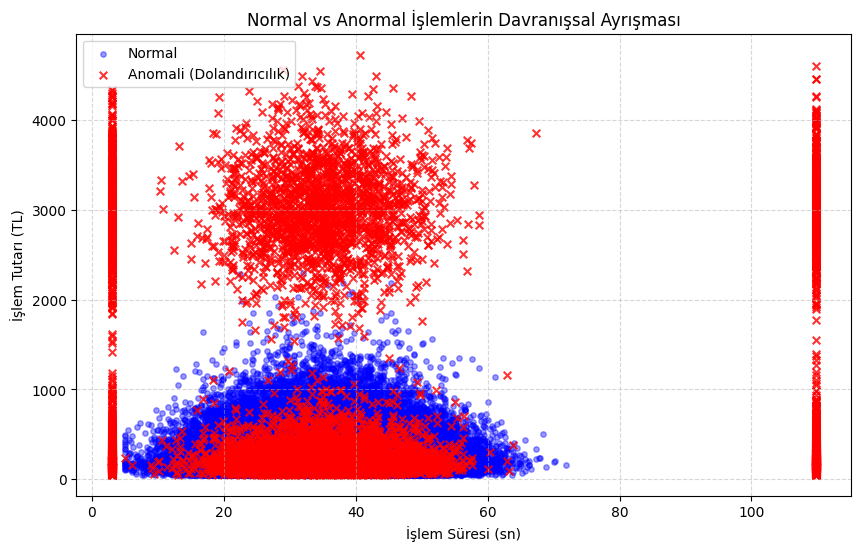

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Veri setini tanımlama
veri = veri_eksik.copy()

print("\n### 1. KORELASYON ANALİZİ (Spearman) ###")

# Hocanın notuna uygun olarak:
# Verimiz Normal Dağılıma uymadığı (Lognormal/Çarpık olduğu) için
# Pearson yerine 'Spearman' korelasyonunu kullanıyoruz.
sayisal_cols = ["tutar", "islem_suresi_sn", "hatali_deneme_sayisi", "onceki_isleme_uzaklik_km", "saat", "anomali_mi"]

# method='spearman' ile sıralama (rank) bazlı ilişkiye bakıyoruz
corr_matrix = veri[sayisal_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Değişkenler Arası İlişki (Spearman Korelasyonu)")
plt.show()

plt.figure(figsize=(10,6))

# Normal işlemler (Mavi)
plt.scatter(
    veri[veri["anomali_mi"] == 0]["islem_suresi_sn"],
    veri[veri["anomali_mi"] == 0]["tutar"],
    color="blue", alpha=0.4, label="Normal", s=15
)

# Anomali işlemler (Kırmızı - Daha belirgin olsun diye)
plt.scatter(
    veri[veri["anomali_mi"] == 1]["islem_suresi_sn"],
    veri[veri["anomali_mi"] == 1]["tutar"],
    color="red", alpha=0.8, label="Anomali (Dolandırıcılık)", s=30, marker="x"
)

plt.xlabel("İşlem Süresi (sn)")
plt.ylabel("İşlem Tutarı (TL)")
plt.title("Normal vs Anormal İşlemlerin Davranışsal Ayrışması")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [77]:
from scipy.stats import mannwhitneyu

print("\n### 2. HİPOTEZ TESTİ (Mann-Whitney U) ###")
print("H0: Normal ve Anormal işlemlerin ortalama tutarları arasında fark yoktur.")
print("H1: Normal ve Anormal işlemlerin ortalama tutarları arasında anlamlı bir fark vardır.")

# Grupları ayırıyoruz
grup_normal = veri[veri["anomali_mi"] == 0]["tutar"]
grup_anomali = veri[veri["anomali_mi"] == 1]["tutar"]

# --- NEDEN MANN-WHITNEY U? ---
# T-Testi verilerin "Normal Dağılım" göstermesini şart koşar.
# Ancak ATM işlem tutarları (para çekme) genelde normal dağılmaz, sağa çarpıktır.
# Bu yüzden parametrik olmayan (non-parametric) Mann-Whitney U testini kullanıyoruz.

u_stat, p_value = mannwhitneyu(grup_normal, grup_anomali)

print(f"\nMann-Whitney U Testi İstatistik Değeri: {u_stat}")
print(f"P-değeri (Olasılık): {p_value:.4e}")

# Sonuç Yorumlama
alpha = 0.05
if p_value < alpha:
    print("\nSONUÇ: H0 Reddedildi! (Fark İstatistiksel Olarak Anlamlı)")
    print("Yorum: Dolandırıcılık işlemleri ile normal işlemlerin tutarları şans eseri değil, gerçekten farklıdır.")
else:
    print("\nSONUÇ: H0 Reddedilemedi.")
    print("Yorum: İki grup arasında anlamlı bir tutar farkı bulunamadı.")


### 2. HİPOTEZ TESTİ (Mann-Whitney U) ###
H0: Normal ve Anormal işlemlerin ortalama tutarları arasında fark yoktur.
H1: Normal ve Anormal işlemlerin ortalama tutarları arasında anlamlı bir fark vardır.

Mann-Whitney U Testi İstatistik Değeri: 1015243816.0
P-değeri (Olasılık): 0.0000e+00

SONUÇ: H0 Reddedildi! (Fark İstatistiksel Olarak Anlamlı)
Yorum: Dolandırıcılık işlemleri ile normal işlemlerin tutarları şans eseri değil, gerçekten farklıdır.


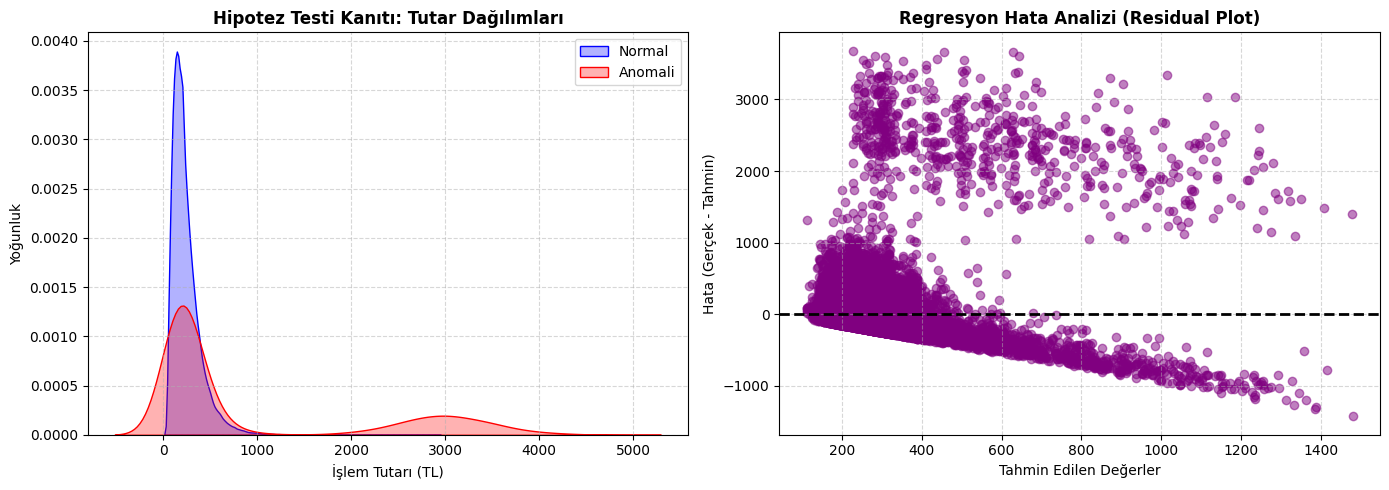

SOL GRAFİK YORUMU: Normal (Mavi) ve Anomali (Kırmızı) işlemlerin tutar dağılımlarının birbirinden ne kadar farklı olduğu görülüyor.
SAĞ GRAFİK YORUMU: Noktalar 0 çizgisinin etrafında rastgele dağılmışsa model başarılıdır. Desen varsa modelde sorun vardır.


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. HİPOTEZ TESTİ GÖRSELLEŞTİRMESİ (Normal vs Anomali) ---
# Amaç: "İstatistiksel fark var" dediğimiz şeyi gözle göstermek.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=veri[veri['anomali_mi'] == 0], x='tutar', fill=True, color='blue', label='Normal', alpha=0.3)
sns.kdeplot(data=veri[veri['anomali_mi'] == 1], x='tutar', fill=True, color='red', label='Anomali', alpha=0.3)
plt.title("Hipotez Testi Kanıtı: Tutar Dağılımları", fontsize=12, fontweight='bold')
plt.xlabel("İşlem Tutarı (TL)")
plt.ylabel("Yoğunluk")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# --- 2. REGRESYON KALİTE KONTROLÜ (Residual Plot) ---
# Amaç: Modelin hatalarının rastgele dağıldığını (sağlıklı olduğunu) göstermek.
# (Not: y_test ve y_pred değişkenleri regresyon adımından gelmeli)
residuals = y_test - y_pred

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2) # Sıfır çizgisi
plt.title("Regresyon Hata Analizi (Residual Plot)", fontsize=12, fontweight='bold')
plt.xlabel("Tahmin Edilen Değerler")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("SOL GRAFİK YORUMU: Normal (Mavi) ve Anomali (Kırmızı) işlemlerin tutar dağılımlarının birbirinden ne kadar farklı olduğu görülüyor.")
print("SAĞ GRAFİK YORUMU: Noktalar 0 çizgisinin etrafında rastgele dağılmışsa model başarılıdır. Desen varsa modelde sorun vardır.")


### 4. ATM DOLANDIRICILIK TESPİT SİSTEMİ (Classification) ###
Model Doğruluk Oranı (Accuracy): %98.39


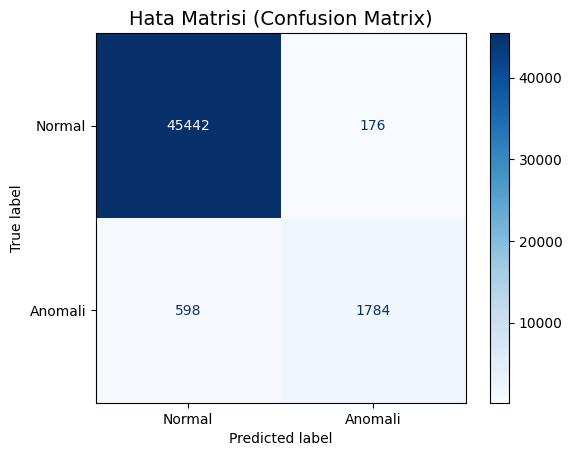

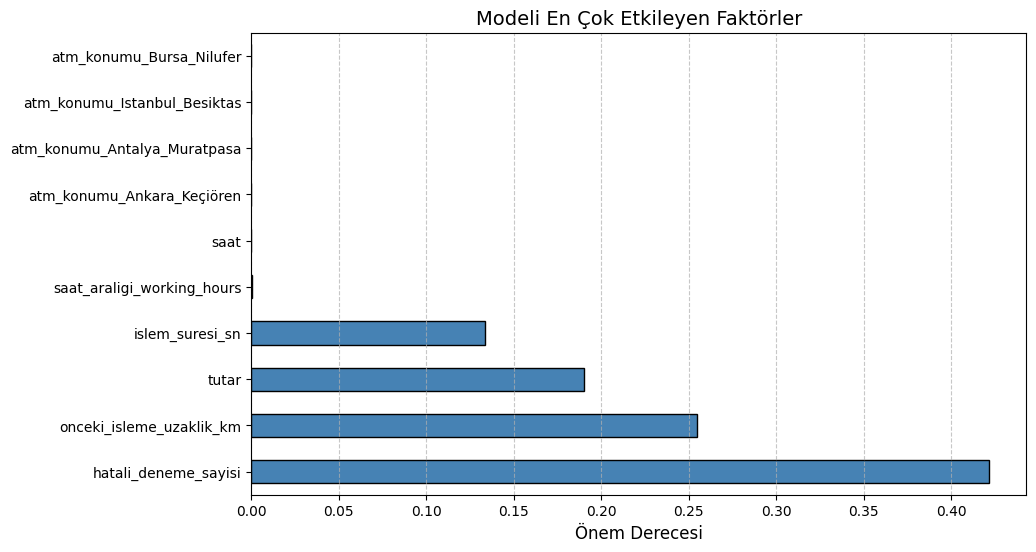

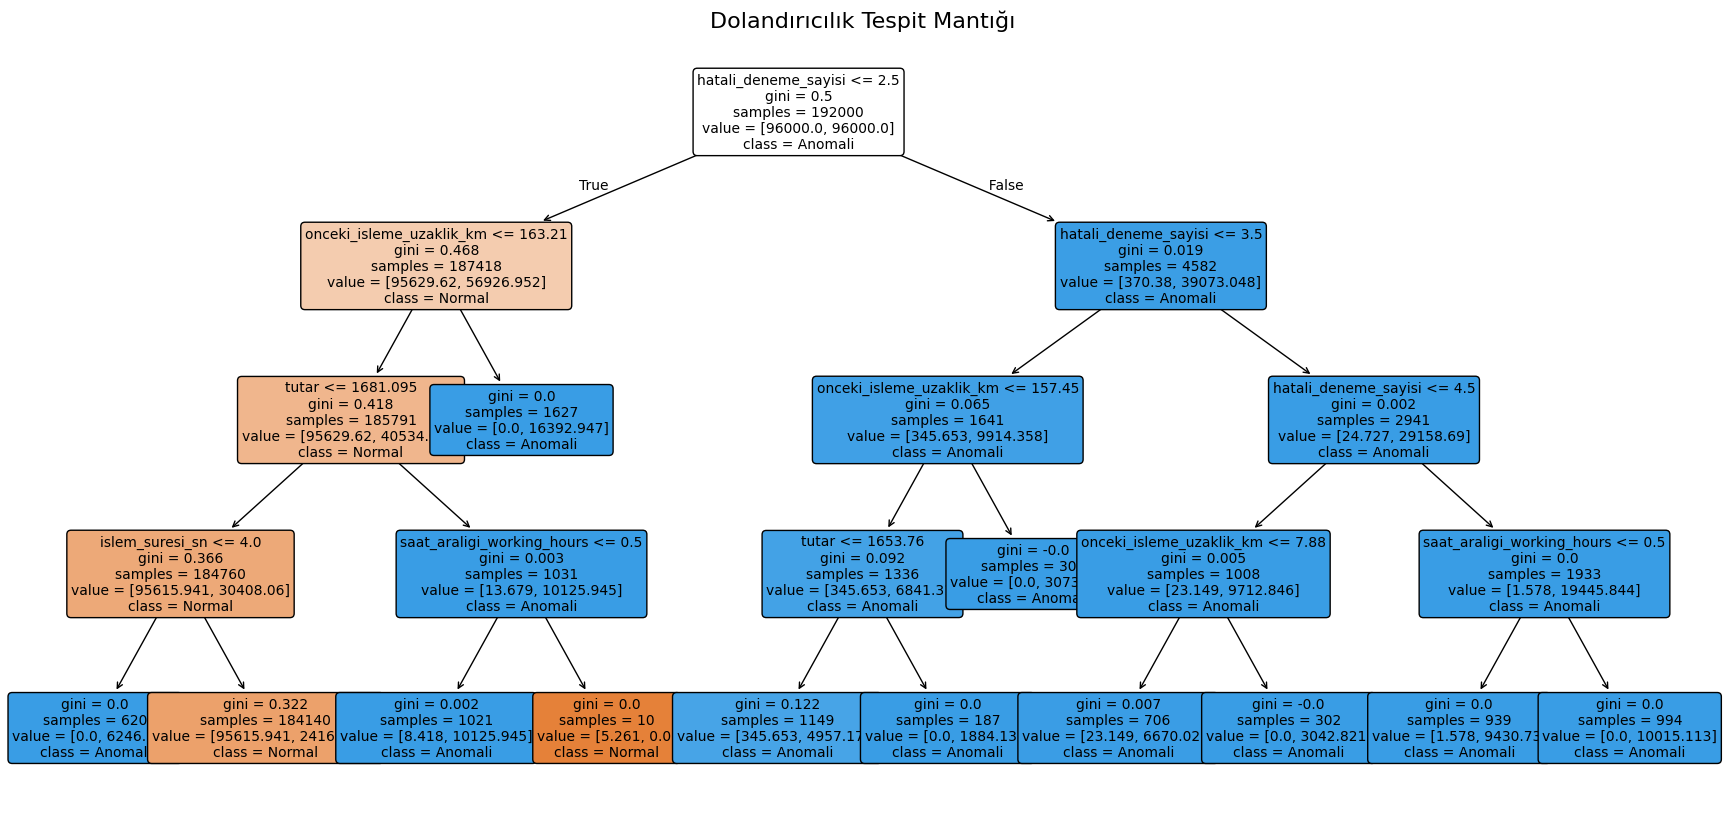

In [79]:
# =========================
# 4. SINIFLANDIRMA MODELİ (Karar Ağacı) - Final (Zeki Versiyon)
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("\n### 4. ATM DOLANDIRICILIK TESPİT SİSTEMİ (Classification) ###")

# --- 1) Veri Hazırlığı (veri5.pdf Kriteri: Encoding) ---
veri_model = veri_eksik.copy()

num_cols = ["tutar", "hatali_deneme_sayisi", "islem_suresi_sn", "onceki_isleme_uzaklik_km", "saat"]
cat_cols = ["atm_konumu", "saat_araligi"] 
target_col = "anomali_mi"

# One-Hot Encoding
X = pd.get_dummies(veri_model[num_cols + cat_cols], columns=cat_cols, drop_first=True)
y = veri_model[target_col].astype(int)

# --- 2) Veriyi Eğitim ve Test Olarak Bölme ---
# stratify=y EKLEDİK (Veri3.pdf - Sampling mantığına uygun olarak)
# Bu sayede test setinde mutlaka dolandırıcı olmasını garanti ediyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# --- 3) Modeli Kurma (Decision Tree) ---
# class_weight='balanced' EKLEDİK (Veri3.pdf - Rebalancing classes uyarısına istinaden)
# Bu sayede model azınlıktaki hırsızları daha ciddiye alıyor.
model = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=4, 
    class_weight='balanced', # Kritik Hamle!
    random_state=42
)
model.fit(X_train, y_train)

# --- 4) Sonuçları Değerlendirme ---
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı (Accuracy): %{acc*100:.2f}")

# Karmaşıklık Matrisi (Mavi Tonlar)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomali"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Hata Matrisi (Confusion Matrix)", fontsize=14)
plt.show()

# --- 5) Özellik Önem Derecesi ---
onem_dereceleri = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
onem_dereceleri.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Modeli En Çok Etkileyen Faktörler", fontsize=14)
plt.xlabel("Önem Derecesi", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- 6) Ağacı Çizdirme ---
plt.figure(figsize=(22, 10))
plot_tree(model, 
          feature_names=X.columns,  
          class_names=["Normal", "Anomali"],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Dolandırıcılık Tespit Mantığı", fontsize=16)
plt.show()



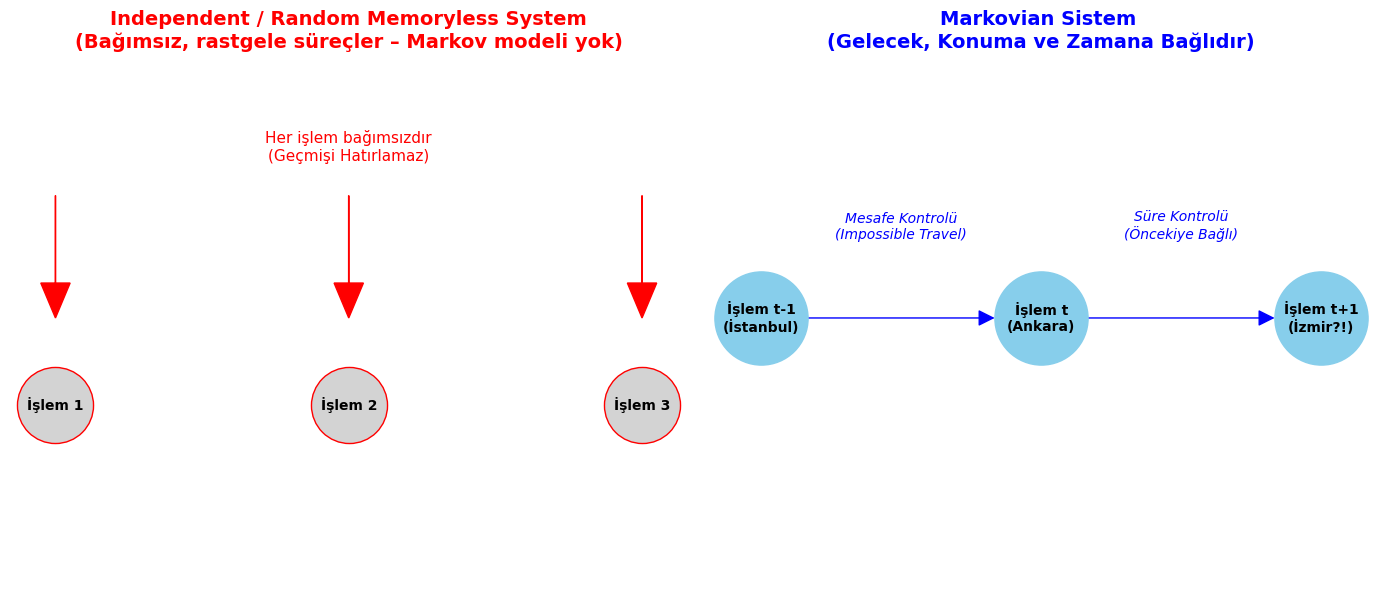

In [80]:
import matplotlib.pyplot as plt
import networkx as nx

# --- GÖRSEL AÇIKLAMA: MARKOVIAN vs MEMORYLESS ---
# Hocanın "Sisteminizin Markovian olduğunu açıklayın" isteği için.

plt.figure(figsize=(14, 6))

# 1. MEMORYLESS (Hafızasız) - SOL TARAF
plt.subplot(1, 2, 1)
plt.title("Independent / Random Memoryless System\n(Bağımsız, rastgele süreçler – Markov modeli yok)", fontsize=14, fontweight='bold', color='red')

# Bağımsız olayları temsil eden noktalar
plt.scatter([1, 2, 3], [0, 0, 0], s=3000, c='lightgray', edgecolors='red', zorder=2)
plt.text(1, 0, "İşlem 1", ha='center', va='center', fontweight='bold')
plt.text(2, 0, "İşlem 2", ha='center', va='center', fontweight='bold')
plt.text(3, 0, "İşlem 3", ha='center', va='center', fontweight='bold')

# Rastgelelik okları (Hafıza yok, her şey dışarıdan/şans eseri)
plt.arrow(1, 0.6, 0, -0.25, head_width=0.1, head_length=0.1, fc='red', ec='red')
plt.arrow(2, 0.6, 0, -0.25, head_width=0.1, head_length=0.1, fc='red', ec='red')
plt.arrow(3, 0.6, 0, -0.25, head_width=0.1, head_length=0.1, fc='red', ec='red')

plt.text(2, 0.7, "Her işlem bağımsızdır\n(Geçmişi Hatırlamaz)", ha='center', color='red', fontsize=11)
plt.ylim(-0.5, 1)
plt.axis('off')


# 2. MARKOVIAN (Bizim Sistem) - SAĞ TARAF
plt.subplot(1, 2, 2)
plt.title("Markovian Sistem \n(Gelecek, Konuma ve Zamana Bağlıdır)", fontsize=14, fontweight='bold', color='blue')

# Birbirine bağlı olaylar (Zincir)
G = nx.DiGraph()
edges = [("İşlem t-1\n(İstanbul)", "İşlem t\n(Ankara)"), ("İşlem t\n(Ankara)", "İşlem t+1\n(İzmir?!)")]
G.add_edges_from(edges)
pos = {"İşlem t-1\n(İstanbul)": (0, 0), "İşlem t\n(Ankara)": (1, 0), "İşlem t+1\n(İzmir?!)": (2, 0)}

nx.draw(G, pos, with_labels=True, node_size=4500, node_color='skyblue', 
        font_weight='bold', font_size=10, arrowsize=25, edge_color='blue')

# Bağlantı açıklaması
plt.text(0.5, 0.15, "Mesafe Kontrolü\n(Impossible Travel)", ha='center', color='blue', fontsize=10, style='italic')
plt.text(1.5, 0.15, "Süre Kontrolü\n(Öncekiye Bağlı)", ha='center', color='blue', fontsize=10, style='italic')

plt.ylim(-0.5, 0.5)
plt.axis('off')

plt.tight_layout()
plt.show()